In [1]:
import ioNERDSS as io
import matplotlib.pyplot as plt
import numpy as np
import pandas

### Load the histogram file ###


In [22]:
#Path to file
path_to_histo = ""

multi_species_01=io.MultiHistogram(FileName=path_to_histo,FileNum=1,InitialTime=0.0,FinalTime=1.0,SpeciesList=["A","B","C"])

data_01 = multi_species_01.hist_to_df(SaveCsv = False)


Text(0, 0.5, 'Copy Number')

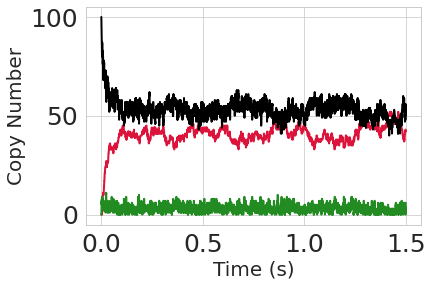

In [3]:
fig,ax = plt.subplots(figsize=(6,4))

lw=2
f_size=20
t_size=25

ax.plot(data_01['Time(s):'].to_numpy(),data_01['A: 1.  B: 1.  C: 1.  '].to_numpy(),linewidth=lw,color='crimson',label='ABC')
ax.plot(data_01['Time(s):'].to_numpy(),data_01['A: 1.  B: 1.  C: 0.  '].to_numpy(),linewidth=lw,color='forestgreen',label='AB')
ax.plot(data_01['Time(s):'].to_numpy(),data_01['A: 1.  B: 0.  C: 0.  '].to_numpy(),linewidth=lw,color='black',label='A')
ax.tick_params(labelsize=t_size)
ax.set_xlabel("Time (s)",fontsize=f_size)
ax.set_ylabel("Copy Number",fontsize=f_size)

In [16]:
print("Final Copies at time: %f sec" %(data_01['Time(s):'].to_numpy()[-1]))
print("ABC: ",data_01['A: 1.  B: 1.  C: 1.  '].to_numpy()[-1])
print("AB: ",data_01['A: 1.  B: 1.  C: 0.  '].to_numpy()[-1])
print("A: ",data_01['A: 1.  B: 0.  C: 0.  '].to_numpy()[-1])


Final Copies at time: 1.500000 sec
ABC:  42.0
AB:  6.0
A:  48.0


## Calculating Time averaged copies ##


In [13]:
#Choose time point to start averaging from
time_point = 0.5

avg_data_ABC = np.mean(data_01['A: 1.  B: 1.  C: 1.  '].to_numpy()[data_01['Time(s):'].to_numpy()>time_point])
avg_data_AB = np.mean(data_01['A: 1.  B: 1.  C: 0.  '].to_numpy()[data_01['Time(s):'].to_numpy()>time_point])
avg_data_A = np.mean(data_01['A: 1.  B: 0.  C: 0.  '].to_numpy()[data_01['Time(s):'].to_numpy()>time_point])
print("Time Averaged ABC copies: ",avg_data_ABC)
print("Time Averaged AB copies: ",avg_data_AB)
print("Time Averaged A copies: ",avg_data_A)


Time Averaged ABC copies:  41.39532093581284
Time Averaged AB copies:  3.016496700659868
Time Averaged A copies:  52.68086382723455


## Calculating Equilibrium Solution for a Heterotrimer


In [2]:
from sympy.solvers import solve
from sympy import symbols
import numpy as np
from sympy import nsolve

In [10]:
#Define Sympy variables
a,b,c,ab,ac,bc,abc = symbols("a,b,c,ab,ac,bc,abc")

#Define rates and other constants
k_on = np.array([1,1,1,1,1,1])      #Units - uM-1 s-1 #Order is dimer reactions the trimer reactions - [kdim,kdim,kdim,ktri,ktri,ktri]
g = np.array([-16.44,-16.44,-16.44,-32.896,-32.896,-32.896])      #Units kJ/mol #Similar order - [dG_dim,dG_dim,dG_dim,dG_tri,dG_tri,dG_tri]
R = 8.314     #Gas constant (J/mol)
T = 310       #Temp in Kelvin
C0 = 1e6      # Standard State Conc #Units- uM

#Get off rates
k_off = C0*k_on*np.exp(g*1000/(R*T))
init_conc = [100,100,100,0,0,0,0]            #Units - uM
# init_sol = np.random.rand(len(init_conc))*max(init_conc)
init_sol = [ 10,  10,  10,  2,  2,  2, 80]     #Initial Guess

#System of rate equations
eq1 = -k_on[0]*a*b - k_on[5]*a*bc -k_on[1]*a*c + k_off[0]*ab + k_off[5]*abc + k_off[1]*ac
eq2 = -k_on[0]*a*b - k_on[2]*b*c - k_on[4]*b*ac + k_off[0]*ab + k_off[4]*abc + k_off[2]*bc
eq3 = -k_on[1]*a*c -k_on[2]*b*c - k_on[3]*c*ab + k_off[1]*ac + k_off[2]*bc + k_off[3]*abc
eq4 = -k_off[0]*ab - k_on[3]*ab*c + k_on[0]*a*b + k_off[3]*abc
eq5 = -k_off[1]*ac - k_on[4]*ac*b + k_on[1]*a*c + k_off[4]*abc
eq6 = -k_off[2]*bc - k_on[5]*bc*a + k_on[2]*b*c + k_off[5]*abc
eq7 = -(k_off[3] + k_off[4] + k_off[5])*abc + k_on[3]*ab*c + k_on[4]*ac*b + k_on[5]*bc*a

#Mass conservation
c1 = a+ab+ac+abc-100.0
c2 = b+ab+bc+abc-100.0
c3 = c+ac+bc+abc-100.0

system = [eq1,eq2,eq3,eq4,eq5,eq6,eq7,c1,c2,c3]

print("Off rates: ",k_off)
print("")

solution = nsolve(system,[a,b,c,ab,ac,bc,abc],init_sol)

print("Final Equilibrium Solution: ")
print("A: ",solution[0])
print("AB: ",solution[3])
print("ABC: ",solution[-1])

Off rates:  [1697.37985112 1697.37985112 1697.37985112    2.86326804    2.86326804
    2.86326804]

Final Equilibrium Solution: 
A:  57.3383716990346
AB:  1.93691993393934
ABC:  38.7877884330867
